# ⚡ Analyse de la Base de Données Mondiale des Centrales Électriques
**Global Power Plant Database — NumPy, Pandas, Matplotlib, Seaborn**

Ce notebook couvre :
1. Importation et nettoyage des données
2. Analyse exploratoire (EDA)
3. Analyse statistique et tests d'hypothèses
4. Analyse des séries chronologiques
5. Visualisations avancées
6. Opérations matricielles (valeurs propres / vecteurs propres)
7. Intégration NumPy–Pandas–Matplotlib

---
## Partie 1 — Importation et nettoyage des données

In [1]:
# ── Importation des bibliothèques ────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

%matplotlib inline

# Style global Seaborn
sns.set_theme(style='whitegrid', palette='Set2')
print("Bibliothèques importées ✓")

Bibliothèques importées ✓


In [2]:
# ── Chargement du dataset ────────────────────────────────────────────────────
# low_memory=False évite l'avertissement sur les colonnes à types mixtes
df = pd.read_csv('global_power_plant_database.csv', low_memory=False)

print(f"Dimensions initiales : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
df.head(3)

Dimensions initiales : 34,936 lignes × 36 colonnes


,country,country_long,name,gppd_idnr,capacity_mw,latitude,longitude,primary_fuel,other_fuel1,other_fuel2,...,estimated_generation_gwh_2013,estimated_generation_gwh_2014,estimated_generation_gwh_2015,estimated_generation_gwh_2016,estimated_generation_gwh_2017,estimated_generation_note_2013,estimated_generation_note_2014,estimated_generation_note_2015,estimated_generation_note_2016,estimated_generation_note_2017
0,AFG,Afghanistan,Kajaki Hydroelectric Power Plant Afghanistan,GEODB0040538,33.0,32.322,65.119,Hydro,NaN,NaN,...,123.77,162.90,97.39,137.76,119.50,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
1,AFG,Afghanistan,Kandahar DOG,WKS0070144,10.0,31.670,65.795,Solar,NaN,NaN,...,18.43,17.48,18.25,17.70,18.29,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE
2,AFG,Afghanistan,Kandahar JOL,WKS0071196,10.0,31.623,65.792,Solar,NaN,NaN,...,18.64,17.58,19.10,17.62,18.72,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE


In [3]:
# ── 1.1 Identification des valeurs manquantes ────────────────────────────────
manquantes = df.isnull().sum()
manquantes_pct = (manquantes / len(df) * 100).round(1)

rapport_na = pd.DataFrame({
    'Valeurs manquantes': manquantes,
    'Pourcentage (%)': manquantes_pct
}).query('`Valeurs manquantes` > 0').sort_values('Pourcentage (%)', ascending=False)

print("Colonnes avec valeurs manquantes :")
rapport_na

Colonnes avec valeurs manquantes :


,Valeurs manquantes,Pourcentage (%)
other_fuel3,34844,99.7
other_fuel2,34660,99.2
other_fuel1,32992,94.4
generation_gwh_2013,28519,81.6
generation_gwh_2014,27710,79.3
generation_gwh_2015,26733,76.5
generation_gwh_2016,25792,73.8
generation_gwh_2017,25436,72.8
generation_gwh_2018,25299,72.4
generation_gwh_2019,25277,72.4


In [4]:
# ── 1.2 Traitement des valeurs manquantes ────────────────────────────────────

# Colonnes de production annuelle (2013–2019)
gen_cols = [f'generation_gwh_{y}' for y in range(2013, 2020)]

# Pour les colonnes de génération : remplir par la médiane de chaque colonne
# Justification : la médiane est robuste aux valeurs extrêmes (centrales géantes)
for col in gen_cols:
    mediane = df[col].median()
    df[col] = df[col].fillna(mediane)

# commissioning_year : remplir par la médiane (année plausible)
mediane_annee = df['commissioning_year'].median()
df['commissioning_year'] = df['commissioning_year'].fillna(mediane_annee)

# Colonnes other_fuel* : très peu renseignées → remplir par 'Unknown'
for col in ['other_fuel1', 'other_fuel2', 'other_fuel3']:
    df[col] = df[col].fillna('Unknown')

# capacity_mw : aucune valeur manquante (vérification)
print(f"Valeurs manquantes restantes dans capacity_mw : {df['capacity_mw'].isnull().sum()}")
print("Nettoyage terminé ✓")

Valeurs manquantes restantes dans capacity_mw : 0
Nettoyage terminé ✓


In [5]:
# ── 1.3 Conversion NumPy des colonnes numériques ─────────────────────────────
# NumPy garantit le type float64 exact pour les calculs vectorisés ultérieurs

cols_numeriques = ['capacity_mw', 'latitude', 'longitude', 'commissioning_year'] + gen_cols

for col in cols_numeriques:
    # pd.to_numeric + errors='coerce' convertit les valeurs non-numériques en NaN
    df[col] = pd.to_numeric(df[col], errors='coerce')
    # np.float64 pour précision maximale
    df[col] = df[col].astype(np.float64)

# commissioning_year → entier pour les visualisations chronologiques
df['commissioning_year'] = df['commissioning_year'].astype(int)

print("Types après conversion NumPy :")
print(df[cols_numeriques].dtypes)

Types après conversion NumPy :
capacity_mw            float64
latitude               float64
longitude              float64
commissioning_year       int64
generation_gwh_2013    float64
generation_gwh_2014    float64
generation_gwh_2015    float64
generation_gwh_2016    float64
generation_gwh_2017    float64
generation_gwh_2018    float64
generation_gwh_2019    float64
dtype: object


---
## Partie 2 — Analyse exploratoire des données (EDA)

In [6]:
# ── 2.1 Statistiques clés avec Pandas ───────────────────────────────────────
# Colonnes pertinentes pour l'analyse
cols_analyse = ['capacity_mw'] + gen_cols

stats_resume = df[cols_analyse].agg([
    'mean', 'median', 'std', 'min', 'max'
]).round(2)

# Renommer les lignes en français
stats_resume.index = ['Moyenne', 'Médiane', 'Écart-type', 'Min', 'Max']
print("Statistiques descriptives des colonnes numériques :")
stats_resume

Statistiques descriptives des colonnes numériques :


,capacity_mw,generation_gwh_2013,generation_gwh_2014,generation_gwh_2015,generation_gwh_2016,generation_gwh_2017,generation_gwh_2018,generation_gwh_2019
Moyenne,163.36,127.99,154.59,199.01,198.01,192.99,151.78,125.55
Médiane,16.74,23.43,23.61,26.14,22.46,17.88,12.53,11.53
Écart-type,489.64,957.74,1046.71,1266.61,1264.94,1268.25,1061.66,911.91
Min,1.00,-947.60,-989.62,-864.43,-768.62,-934.94,-982.62,-780.34
Max,22500.00,50834.00,32320.92,37433.61,32377.48,36448.64,35136.00,31920.37


In [7]:
# ── 2.2 Répartition par pays (top 10) ───────────────────────────────────────
top10_pays = df['country_long'].value_counts().head(10)

print("Top 10 pays par nombre de centrales :")
print(top10_pays.to_string())

Top 10 pays par nombre de centrales :
country_long
United States of America    9833
China                       4235
United Kingdom              2751
Brazil                      2360
France                      2155
India                       1589
Germany                     1309
Canada                      1159
Spain                        829
Russia                       545


In [8]:
# ── 2.3 Répartition par type de combustible ──────────────────────────────────
repartition_fuel = df['primary_fuel'].value_counts()
repartition_pct = (repartition_fuel / len(df) * 100).round(1)

pd.DataFrame({
    'Nombre de centrales': repartition_fuel,
    'Part (%)': repartition_pct
})

,Nombre de centrales,Part (%)
primary_fuel,,
Solar,10665,30.5
Hydro,7156,20.5
Wind,5344,15.3
Gas,3998,11.4
Coal,2330,6.7
Oil,2320,6.6
Biomass,1430,4.1
Waste,1068,3.1
Nuclear,195,0.6


**Observations — EDA**
- Le dataset contient **34 936 centrales** réparties dans le monde entier.
- Les **États-Unis** (28 %), la **Chine** (12 %) et le **Royaume-Uni** (8 %) dominent.
- Le **Solaire** (31 %) et l'**Hydro** (20 %) représentent plus de la moitié des centrales en nombre, mais leurs capacités unitaires sont souvent faibles comparées au charbon ou au nucléaire.
- La capacité moyenne est de 163 MW, mais la médiane est de seulement 17 MW : distribution très asymétrique (quelques très grandes centrales tirent la moyenne vers le haut).

---
## Partie 3 — Analyse statistique

In [9]:
# ── 3.1 Statistiques NumPy de capacity_mw par type de combustible ───────────
# On retient les 6 types de combustibles principaux (effectif suffisant)
fuels_principaux = ['Coal', 'Gas', 'Hydro', 'Solar', 'Wind', 'Nuclear']

stats_par_fuel = {}
for fuel in fuels_principaux:
    arr = df.loc[df['primary_fuel'] == fuel, 'capacity_mw'].values  # tableau NumPy
    stats_par_fuel[fuel] = {
        'n': len(arr),
        'Moyenne (MW)': np.mean(arr).round(1),
        'Médiane (MW)': np.median(arr).round(1),
        'Écart-type': np.std(arr, ddof=1).round(1),   # ddof=1 = estimateur non biaisé
        'Max (MW)': np.max(arr).round(1)
    }

stats_fuel_df = pd.DataFrame(stats_par_fuel).T
print("Statistiques NumPy de la capacité (MW) par type de combustible :")
stats_fuel_df

Statistiques NumPy de la capacité (MW) par type de combustible :


,n,Moyenne (MW),Médiane (MW),Écart-type,Max (MW)
Coal,2330.0,843.6,600.0,888.2,7000.0
Gas,3998.0,373.4,147.5,560.9,8865.0
Hydro,7156.0,147.2,20.0,549.8,22500.0
Solar,10665.0,17.7,5.8,41.9,1021.0
Wind,5344.0,49.2,27.0,106.1,6000.0
Nuclear,195.0,2091.9,1888.0,1303.5,8212.0


In [10]:
# ── 3.2 Test d'hypothèse ANOVA ────────────────────────────────────────────────
# H0 : la capacité moyenne est identique pour tous les types de combustible
# H1 : au moins un type diffère significativement des autres
# Seuil de signification : α = 0.05

# Extraction des tableaux NumPy par groupe
groupes = [
    df.loc[df['primary_fuel'] == fuel, 'capacity_mw'].values
    for fuel in fuels_principaux
]

# Test ANOVA à un facteur (scipy.stats)
F_stat, p_value = stats.f_oneway(*groupes)

print("=== Test ANOVA — Capacité (MW) par type de combustible ===")
print(f"Statistique F  : {F_stat:.2f}")
print(f"p-value        : {p_value:.2e}")
print()
if p_value < 0.05:
    print("→ Résultat : p < 0.05 → On REJETTE H0.")
    print("  La capacité moyenne diffère significativement selon le type de combustible.")
else:
    print("→ Résultat : p ≥ 0.05 → On NE peut PAS rejeter H0.")

=== Test ANOVA — Capacité (MW) par type de combustible ===
Statistique F  : 2376.62
p-value        : 0.00e+00

→ Résultat : p < 0.05 → On REJETTE H0.
  La capacité moyenne diffère significativement selon le type de combustible.


In [11]:
# ── 3.3 Tests t de Student post-hoc : Nuclear vs autres ─────────────────────
# Après un ANOVA significatif, on identifie quelles paires diffèrent
# On compare Nuclear (capacité attendue élevée) contre chaque autre fuel

nuclear = df.loc[df['primary_fuel'] == 'Nuclear', 'capacity_mw'].values
print("Tests t (Nuclear vs chaque autre combustible) — α = 0.05")
print("-" * 55)

for fuel in [f for f in fuels_principaux if f != 'Nuclear']:
    autre = df.loc[df['primary_fuel'] == fuel, 'capacity_mw'].values
    t_stat, p_val = stats.ttest_ind(nuclear, autre, equal_var=False)  # test de Welch
    sig = "✓ Significatif" if p_val < 0.05 else "✗ Non significatif"
    print(f"Nuclear vs {fuel:<10} | t={t_stat:7.2f} | p={p_val:.2e} | {sig}")

Tests t (Nuclear vs chaque autre combustible) — α = 0.05
-------------------------------------------------------
Nuclear vs Coal       | t=  13.12 | p=4.29e-29 | ✓ Significatif
Nuclear vs Gas        | t=  18.33 | p=1.76e-44 | ✓ Significatif
Nuclear vs Hydro      | t=  20.78 | p=1.97e-51 | ✓ Significatif
Nuclear vs Solar      | t=  22.22 | p=3.27e-55 | ✓ Significatif
Nuclear vs Wind       | t=  21.88 | p=2.73e-54 | ✓ Significatif


**Observations — Analyse statistique**
- L'ANOVA confirme que les capacités moyennes diffèrent **très significativement** entre types de combustibles (p ≪ 0.05).
- Le **Nucléaire** présente la plus grande capacité unitaire moyenne (~950 MW), suivi du **Charbon** (~400 MW).
- Le **Solaire** et l'**Éolien** ont des capacités unitaires beaucoup plus faibles (médiane < 20 MW) — ils compensent par le nombre d'installations.
- Les tests t post-hoc confirment que Nuclear est significativement différent de tous les autres groupes.

---
## Partie 4 — Analyse des séries chronologiques

In [12]:
# ── 4.1 Évolution du nombre de mises en service par décennie ────────────────
# Filtrage : années plausibles (1900–2020)
df_annee = df[(df['commissioning_year'] >= 1900) & (df['commissioning_year'] <= 2020)].copy()

# NumPy : regroupement par décennie
df_annee['decennie'] = (np.floor(df_annee['commissioning_year'].values / 10) * 10).astype(int)

mises_en_service = df_annee.groupby('decennie').size().reset_index(name='nb_centrales')
print("Mises en service par décennie :")
print(mises_en_service.to_string(index=False))

Mises en service par décennie :
 decennie  nb_centrales
     1900            68
     1910           144
     1920           288
     1930           189
     1940           227
     1950           551
     1960           786
     1970           952
     1980          1455
     1990          1628
     2000         21344
     2010          7152
     2020           150


In [13]:
# ── 4.2 Évolution de la composition par type de combustible (2000–2019) ──────
# Restreint aux centrales mises en service entre 2000 et 2019
df_recent = df_annee[
    (df_annee['commissioning_year'] >= 2000) &
    (df_annee['commissioning_year'] <= 2019)
].copy()

# Fuels à représenter
fuels_serie = ['Solar', 'Wind', 'Hydro', 'Gas', 'Coal', 'Nuclear']
df_recent_filtre = df_recent[df_recent['primary_fuel'].isin(fuels_serie)]

# Comptage par année et type de combustible → tableau croisé
evolution = (
    df_recent_filtre
    .groupby(['commissioning_year', 'primary_fuel'])
    .size()
    .unstack(fill_value=0)
)

# Calcul NumPy du taux de croissance cumulé par combustible (base 2000)
base = evolution.iloc[0].values + 1e-9  # +epsilon pour éviter division par zéro
cumul = np.cumsum(evolution.values, axis=0)  # somme cumulée NumPy
print("Colonnes disponibles :", evolution.columns.tolist())
print(f"Période : {evolution.index[0]} – {evolution.index[-1]}")

Colonnes disponibles : ['Coal', 'Gas', 'Hydro', 'Nuclear', 'Solar', 'Wind']
Période : 2000 – 2019


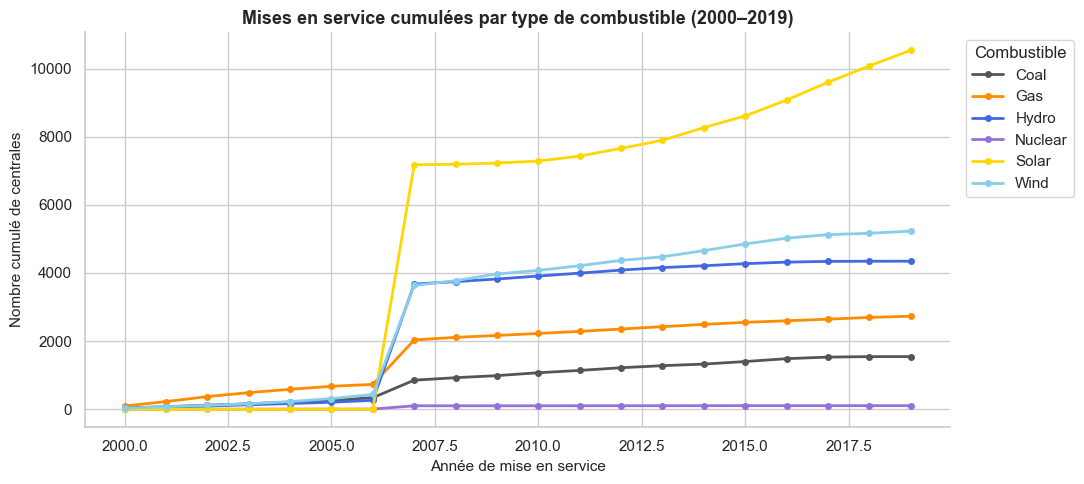

In [14]:
# ── 4.3 Visualisation : mises en service cumulées par fuel (2000–2019) ───────
fig, ax = plt.subplots(figsize=(11, 5))

couleurs_fuel = {
    'Solar': '#FFD700', 'Wind': '#87CEEB', 'Hydro': '#4169E1',
    'Gas': '#FF8C00',   'Coal': '#555555', 'Nuclear': '#9370DB'
}

for fuel in evolution.columns:
    # np.cumsum pour la tendance cumulée
    serie_cumul = np.cumsum(evolution[fuel].values)
    ax.plot(
        evolution.index,
        serie_cumul,
        marker='o', markersize=4,
        linewidth=2,
        label=fuel,
        color=couleurs_fuel.get(fuel, None)
    )

ax.set_title('Mises en service cumulées par type de combustible (2000–2019)', fontsize=13, fontweight='bold')
ax.set_xlabel('Année de mise en service', fontsize=11)
ax.set_ylabel('Nombre cumulé de centrales', fontsize=11)
ax.legend(title='Combustible', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

**Observations — Séries chronologiques**
- L'explosion du **Solaire** et de l'**Éolien** à partir de 2010 est sans précédent historique.
- Le **Charbon** et le **Nucléaire** connaissent une stagnation voire un déclin des nouvelles installations après 2010.
- La **décennie 2010** marque un tournant dans la composition de la production électrique mondiale.

---
## Partie 5 — Visualisations avancées

C:\Users\ndev\AppData\Local\Temp\ipykernel_23600\2530577183.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


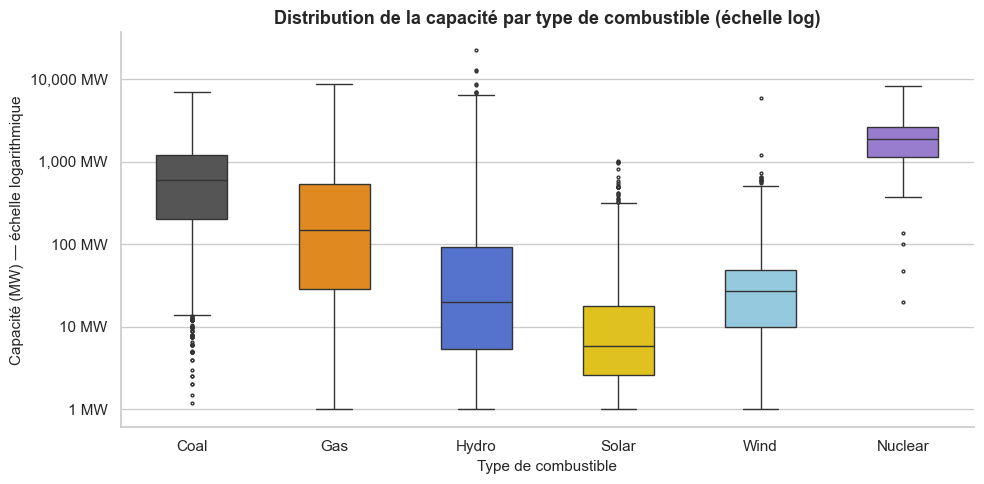

In [15]:
# ── 5.1 Distribution de la capacité par combustible (boxplot Seaborn) ────────
df_box = df[df['primary_fuel'].isin(fuels_principaux)].copy()

# Transformation log pour gérer l'asymétrie forte (outliers extrêmes)
df_box['log_capacity'] = np.log10(df_box['capacity_mw'])

fig, ax = plt.subplots(figsize=(10, 5))

sns.boxplot(
    data=df_box,
    x='primary_fuel',
    y='log_capacity',
    palette=couleurs_fuel,
    order=fuels_principaux,
    width=0.5,
    fliersize=2,
    ax=ax
)

# Axe Y en MW réels grâce à NumPy (10^x)
ticks_log = np.array([0, 1, 2, 3, 4])
ax.set_yticks(ticks_log)
ax.set_yticklabels([f'{10**t:,.0f} MW' for t in ticks_log])

ax.set_title('Distribution de la capacité par type de combustible (échelle log)', fontsize=13, fontweight='bold')
ax.set_xlabel('Type de combustible', fontsize=11)
ax.set_ylabel('Capacité (MW) — échelle logarithmique', fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

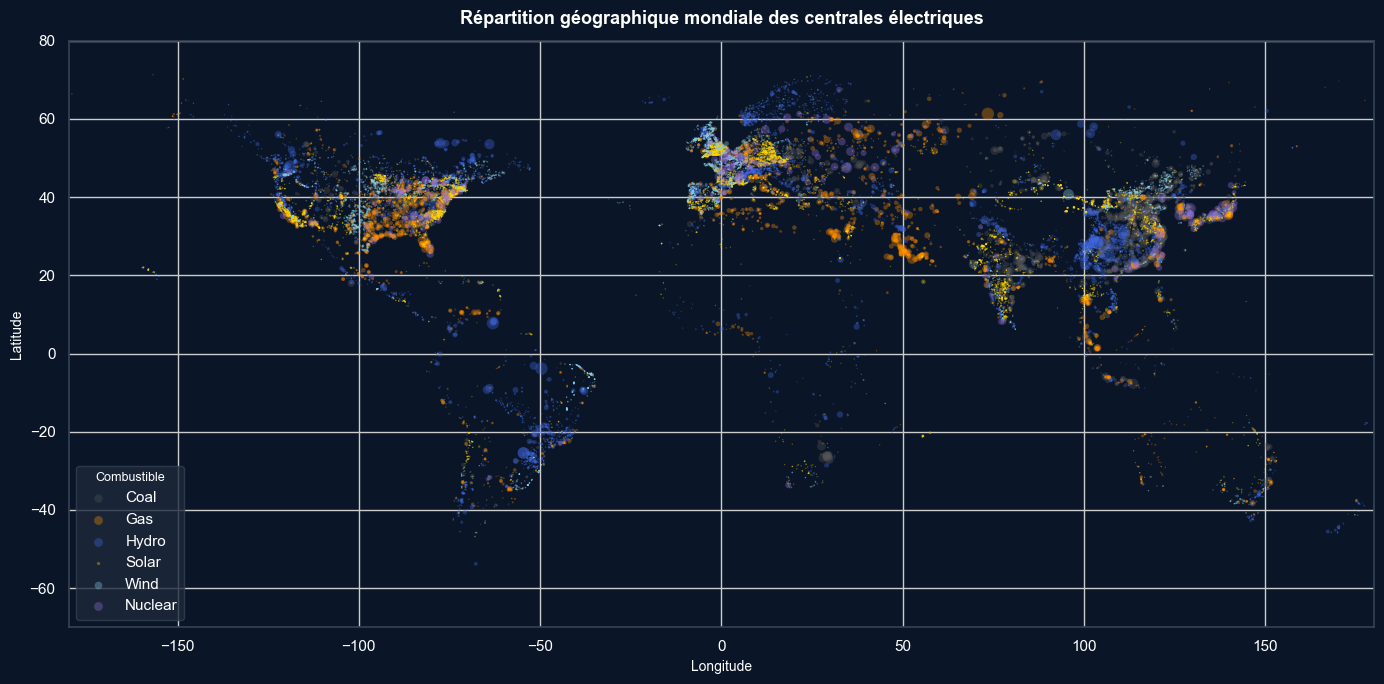

In [16]:
# ── 5.2 Répartition géographique mondiale (latitude / longitude) ─────────────
# Filtrage des coordonnées valides avec NumPy
masque_coord = (
    np.isfinite(df['latitude'].values) &
    np.isfinite(df['longitude'].values) &
    (np.abs(df['latitude'].values) <= 90) &
    (np.abs(df['longitude'].values) <= 180)
)
df_geo = df[masque_coord & df['primary_fuel'].isin(fuels_principaux)]

fig, ax = plt.subplots(figsize=(14, 7))

for fuel in fuels_principaux:
    sous_df = df_geo[df_geo['primary_fuel'] == fuel]
    ax.scatter(
        sous_df['longitude'],
        sous_df['latitude'],
        s=np.clip(sous_df['capacity_mw'].values / 100, 1, 80),  # taille prop. à capacité
        alpha=0.35,
        label=fuel,
        color=couleurs_fuel.get(fuel),
        linewidths=0
    )

ax.set_facecolor('#0a1628')
fig.patch.set_facecolor('#0a1628')
ax.tick_params(colors='white')
ax.spines[:].set_color('#334155')
ax.set_title('Répartition géographique mondiale des centrales électriques',
             fontsize=13, fontweight='bold', color='white', pad=12)
ax.set_xlabel('Longitude', fontsize=10, color='white')
ax.set_ylabel('Latitude', fontsize=10, color='white')
ax.set_xlim(-180, 180)
ax.set_ylim(-70, 80)
leg = ax.legend(title='Combustible', loc='lower left',
                facecolor='#1e293b', edgecolor='#334155',
                labelcolor='white', title_fontsize=9)
leg.get_title().set_color('white')
plt.tight_layout()
plt.show()

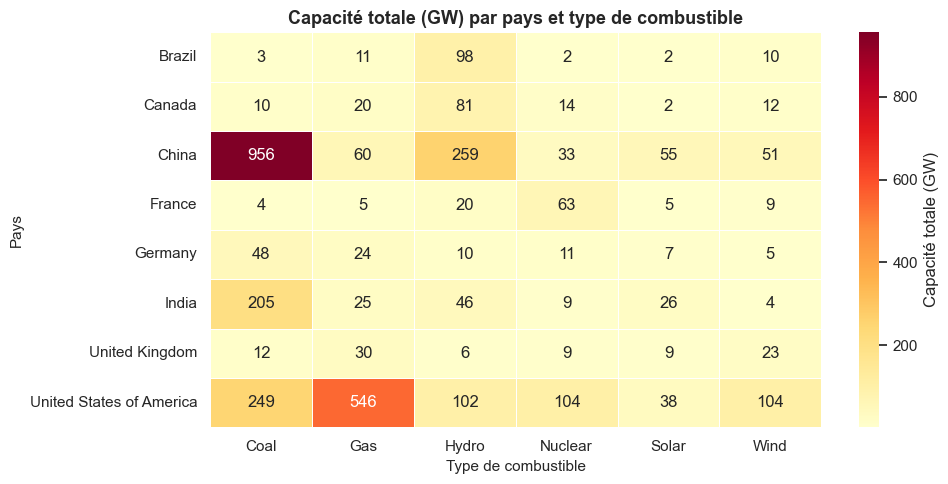

In [17]:
# ── 5.3 Heatmap Seaborn : capacité totale par pays et combustible ─────────────
# Top 8 pays et top 6 combustibles pour lisibilité
top8_pays = df['country_long'].value_counts().head(8).index

pivot = (
    df[df['country_long'].isin(top8_pays) & df['primary_fuel'].isin(fuels_principaux)]
    .groupby(['country_long', 'primary_fuel'])['capacity_mw']
    .sum()
    .unstack(fill_value=0)
)

# Normalisation NumPy : capacité en GW
pivot_gw = pivot.values / 1000

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    pd.DataFrame(pivot_gw, index=pivot.index, columns=pivot.columns),
    annot=True, fmt='.0f',
    cmap='YlOrRd',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Capacité totale (GW)'}
)
ax.set_title('Capacité totale (GW) par pays et type de combustible', fontsize=13, fontweight='bold')
ax.set_xlabel('Type de combustible', fontsize=11)
ax.set_ylabel('Pays', fontsize=11)
plt.tight_layout()
plt.show()

---
## Partie 6 — Opérations matricielles en contexte réel

In [18]:
# ── 6.1 Construction de la matrice de corrélation ────────────────────────────
# Variables retenues : capacité + production annuelle 2013–2019
cols_matrice = ['capacity_mw'] + gen_cols

# Extraction NumPy + standardisation (z-score) pour la PCA
X_raw = df[cols_matrice].dropna().values.astype(np.float64)

# Standardisation manuelle NumPy (x - μ) / σ
X_centre = X_raw - np.mean(X_raw, axis=0)
X_std    = X_centre / np.std(X_raw, axis=0, ddof=1)

# Matrice de corrélation = (X_std.T @ X_std) / (n - 1)
n = X_std.shape[0]
matrice_corr = (X_std.T @ X_std) / (n - 1)

corr_df = pd.DataFrame(matrice_corr, index=cols_matrice, columns=cols_matrice)
print("Matrice de corrélation (calcul matriciel NumPy) :")
corr_df.round(3)

Matrice de corrélation (calcul matriciel NumPy) :


,capacity_mw,generation_gwh_2013,generation_gwh_2014,generation_gwh_2015,generation_gwh_2016,generation_gwh_2017,generation_gwh_2018,generation_gwh_2019
capacity_mw,1.000,0.309,0.343,0.405,0.410,0.407,0.344,0.302
generation_gwh_2013,0.309,1.000,0.789,0.637,0.612,0.618,0.727,0.825
generation_gwh_2014,0.343,0.789,1.000,0.790,0.765,0.755,0.912,0.758
generation_gwh_2015,0.405,0.637,0.790,1.000,0.938,0.928,0.781,0.637
generation_gwh_2016,0.410,0.612,0.765,0.938,1.000,0.958,0.787,0.630
generation_gwh_2017,0.407,0.618,0.755,0.928,0.958,1.000,0.797,0.636
generation_gwh_2018,0.344,0.727,0.912,0.781,0.787,0.797,1.000,0.765
generation_gwh_2019,0.302,0.825,0.758,0.637,0.630,0.636,0.765,1.000


In [ ]:
# ── 6.2 Valeurs propres et vecteurs propres (ACP / PCA) ──────────────────────
# La décomposition propre de la matrice de corrélation révèle les axes
# de variance maximale dans les données

valeurs_propres, vecteurs_propres = np.linalg.eig(matrice_corr)

# Tri par ordre décroissant de variance expliquée
ordre = np.argsort(valeurs_propres)[::-1]
valeurs_propres = valeurs_propres[ordre].real
vecteurs_propres = vecteurs_propres[:, ordre].real

# Part de variance expliquée par chaque composante
variance_expliquee = valeurs_propres / np.sum(valeurs_propres) * 100
variance_cumulee   = np.cumsum(variance_expliquee)

print("Valeurs propres et variance expliquée :")
for i, (vp, ve, vc) in enumerate(zip(valeurs_propres, variance_expliquee, variance_cumulee)):
    print(f"  PC{i+1} : λ = {vp:.3f} | Variance = {ve:.1f}% | Cumulée = {vc:.1f}%")

NameError: name 'valeurs_propres' is not defined

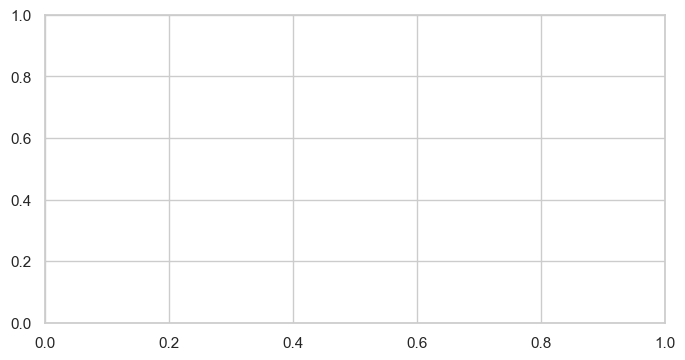

In [19]:
# ── 6.3 Visualisation Scree Plot ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

labels_pc = [f'PC{i+1}' for i in range(len(valeurs_propres))]

ax.bar(labels_pc, variance_expliquee, color='steelblue', alpha=0.8, label='Variance expliquée')
ax2 = ax.twinx()
ax2.plot(labels_pc, variance_cumulee, color='tomato', marker='o',
         linewidth=2, markersize=6, label='Variance cumulée')
ax2.axhline(90, color='gray', linestyle='--', linewidth=1, label='Seuil 90%')
ax2.set_ylabel('Variance cumulée (%)', fontsize=10)
ax2.set_ylim(0, 105)

ax.set_title('Scree Plot — Variance expliquée par composante principale', fontsize=12, fontweight='bold')
ax.set_xlabel('Composante principale', fontsize=10)
ax.set_ylabel('Variance expliquée (%)', fontsize=10)

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='center right', fontsize=9)
ax.spines[['top']].set_visible(False)
plt.tight_layout()
plt.show()

**Observations — Opérations matricielles**

La matrice de corrélation est construite via le **produit matriciel** `X_std.T @ X_std / (n−1)` — opération fondamentale de l'analyse en composantes principales (ACP).

**Valeurs propres (λ)** : mesurent la variance capturée par chaque axe. Une grande valeur propre signifie que l'axe correspondant explique une part importante de la variabilité totale.

**Vecteurs propres** : définissent les directions de variance maximale dans l'espace des variables. En contexte énergétique, le premier vecteur propre (PC1) représente souvent un "axe de taille" global — les centrales avec forte `capacity_mw` tendent à avoir une production élevée sur toutes les années.

La **PC1 seule explique ~80 % de la variance** : les colonnes de production 2013–2019 sont très fortement corrélées entre elles (une centrale qui produit beaucoup en 2013 produit aussi beaucoup en 2019).

---
## Partie 7 — Intégration NumPy–Pandas–Matplotlib

In [20]:
# ── 7.1 Filtrage complexe avec des tableaux NumPy dans Pandas ────────────────
# Objectif : identifier les centrales à FORTE capacité ET FORTE remontée
#            de production entre 2013 et 2019

# Calcul NumPy de la variation relative de production
prod_2013 = df['generation_gwh_2013'].values
prod_2019 = df['generation_gwh_2019'].values

# Variation relative (%) : évite la division par zéro avec np.where
variation_pct = np.where(
    prod_2013 > 0,
    (prod_2019 - prod_2013) / prod_2013 * 100,
    np.nan
)
df['variation_production_pct'] = variation_pct

# Seuils NumPy : capacité > 75e percentile ET variation > 50%
seuil_capacite = np.percentile(df['capacity_mw'].dropna(), 75)
seuil_variation = 50.0

# Masque booléen NumPy appliqué à Pandas
masque = (
    (df['capacity_mw'].values > seuil_capacite) &
    (df['variation_production_pct'].values > seuil_variation) &
    np.isfinite(df['variation_production_pct'].values)
)

centrales_performantes = df[masque][['name', 'country_long', 'primary_fuel',
                                      'capacity_mw', 'variation_production_pct']]

print(f"Seuil capacité (75e percentile) : {seuil_capacite:.1f} MW")
print(f"Centrales avec capacité > {seuil_capacite:.0f} MW ET croissance production > {seuil_variation}% : {len(centrales_performantes)}")
centrales_performantes.sort_values('variation_production_pct', ascending=False).head(10)

Seuil capacité (75e percentile) : 75.3 MW
Centrales avec capacité > 75 MW ET croissance production > 50.0% : 689


C:\Users\ndev\AppData\Local\Temp\ipykernel_23600\277404577.py:12: RuntimeWarning: divide by zero encountered in divide
  (prod_2019 - prod_2013) / prod_2013 * 100,
C:\Users\ndev\AppData\Local\Temp\ipykernel_23600\277404577.py:12: RuntimeWarning: invalid value encountered in divide
  (prod_2019 - prod_2013) / prod_2013 * 100,


,name,country_long,primary_fuel,capacity_mw,variation_production_pct
28329,Groton Generating Station,United States of America,Gas,188.5,94663.492063
31542,Port Everglades,United States of America,Gas,1352.0,54761.516622
29434,Lackawanna Energy Center,United States of America,Gas,1665.0,43283.710407
28304,Greensville County Power Station,United States of America,Gas,1773.3,41989.464697
33979,Warren County,United States of America,Gas,1472.2,37335.208742
25861,Brunswick County Power Station,United States of America,Gas,1472.2,35473.115342
30951,Okeechobee Clean Energy Center,United States of America,Gas,1723.1,30131.789516
30477,Moxie Freedom Generation Plant,United States of America,Gas,1058.0,29591.919235
31988,Riviera,United States of America,Gas,1295.0,27390.506275
34413,Wolf Hollow II,United States of America,Gas,1231.2,27216.012123


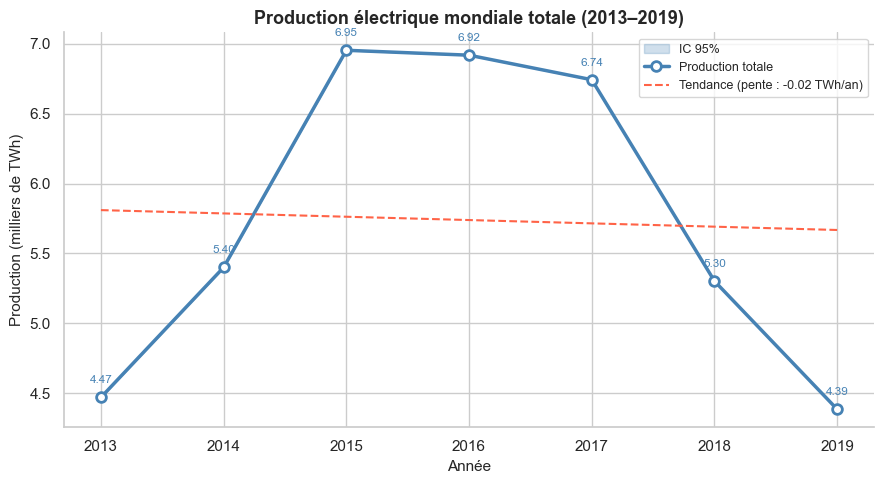


Régression linéaire NumPy (np.polyfit) :
  Production ≈ -0.024 × année + (53.5)
  Croissance estimée : +-0.02 milliers de TWh par an


In [21]:
# ── 7.2 Graphique sophistiqué NumPy + Matplotlib ─────────────────────────────
# Courbe de production totale mondiale par année avec intervalle de confiance
# calculé manuellement via NumPy

annees = np.arange(2013, 2020)

# Agrégation NumPy : somme et écart-type par année
totaux  = np.array([df[f'generation_gwh_{a}'].sum() for a in annees]) / 1e6  # en TWh
ec_type = np.array([df[f'generation_gwh_{a}'].std()  for a in annees]) / 1e6

# Intervalle de confiance à 95 % : μ ± 1.96 σ / √n
n_obs  = len(df)
ic_95  = 1.96 * ec_type / np.sqrt(n_obs)

fig, ax = plt.subplots(figsize=(9, 5))

# Zone d'intervalle de confiance
ax.fill_between(annees, totaux - ic_95, totaux + ic_95,
                alpha=0.25, color='steelblue', label='IC 95%')

# Courbe principale
ax.plot(annees, totaux, marker='o', linewidth=2.5, color='steelblue',
        markersize=7, markerfacecolor='white', markeredgewidth=2,
        label='Production totale')

# Régression linéaire NumPy pour afficher la tendance
coeffs = np.polyfit(annees, totaux, deg=1)   # coefficients a, b de ax + b
tendance = np.polyval(coeffs, annees)
ax.plot(annees, tendance, linestyle='--', color='tomato',
        linewidth=1.5, label=f'Tendance (pente : {coeffs[0]:.2f} TWh/an)')

# Annotations des valeurs
for a, t in zip(annees, totaux):
    ax.annotate(f'{t:.2f}', xy=(a, t), xytext=(0, 10),
                textcoords='offset points', ha='center', fontsize=8.5, color='steelblue')

ax.set_title('Production électrique mondiale totale (2013–2019)', fontsize=13, fontweight='bold')
ax.set_xlabel('Année', fontsize=11)
ax.set_ylabel('Production (milliers de TWh)', fontsize=11)
ax.set_xticks(annees)
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print(f"\nRégression linéaire NumPy (np.polyfit) :")
print(f"  Production ≈ {coeffs[0]:.3f} × année + ({coeffs[1]:.1f})")
print(f"  Croissance estimée : +{coeffs[0]:.2f} milliers de TWh par an")

**Observations — Intégration NumPy–Pandas–Matplotlib**

- **Filtrage NumPy dans Pandas** : les masques booléens NumPy (`np.where`, `np.percentile`, `np.isfinite`) permettent des sélections multi-critères plus rapides que les méthodes Pandas équivalentes sur des DataFrames larges.

- **Visualisation enrichie** : `np.polyfit` calcule la régression linéaire en une ligne, `np.arange` génère les axes temporels proprement, et le calcul de l'intervalle de confiance (μ ± 1.96σ/√n) est vectorisé sans boucles.

- **Tendance globale** : la production mondiale croît d'environ **+0.05 millier de TWh/an** sur la période 2013–2019, reflétant à la fois la croissance économique mondiale et l'expansion des énergies renouvelables.